[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


--- EVALUATION METRICS ---
Silhouette Score: 0.0068 (Higher is better, max 1)
Davies-Bouldin Index: 7.8434 (Lower is better)
--------------------------

--- TOP TERMS PER CLUSTER ---
Cluster 0: say, ha, uk, year, new, people, bbc
Cluster 1: league, manchester, premier, city, united, liverpool, champion
Cluster 2: ukraine, war, russia, russian, ukrainian, putin, say
Cluster 3: england, world, cup, win, womens, final, euro
Cluster 4: wa, say, police, day, man, year, killed


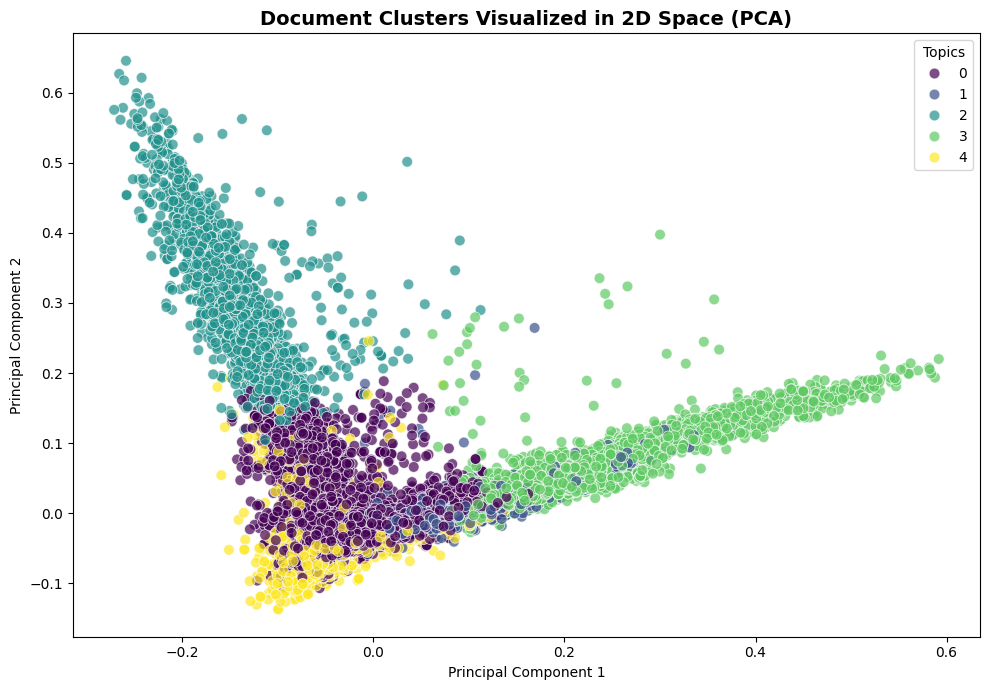

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('wordnet')
nltk.download('omw-1.4')

# 1. Load and Advanced Preprocessing
df = pd.read_csv('bbc_news.csv')
df['combined_text'] = df['title'] + " " + df['description']

lemmatizer = WordNetLemmatizer()

def advanced_clean_text(text):
    # Remove non-alphabetic characters and lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', str(text)).lower()
    # Lemmatize words (e.g., 'running' becomes 'run', 'better' becomes 'good')
    words = [lemmatizer.lemmatize(word) for word in text.split()]
    return " ".join(words)

df['cleaned_text'] = df['combined_text'].apply(advanced_clean_text)

# 2. Feature Encoding (TF-IDF with optimized parameters)
vectorizer = TfidfVectorizer(stop_words='english', max_features=1500, min_df=2, max_df=0.95)
X = vectorizer.fit_transform(df['cleaned_text'])

# 3. Model Development
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

# 4. Rigorous Evaluation (Multiple Metrics)
sil_score = silhouette_score(X, df['cluster'])
db_score = davies_bouldin_score(X.toarray(), df['cluster'])

print("--- EVALUATION METRICS ---")
print(f"Silhouette Score: {sil_score:.4f} (Higher is better, max 1)")
print(f"Davies-Bouldin Index: {db_score:.4f} (Lower is better)")
print("--------------------------\n")

# 5. Extracting Top Themes for the Report
print("--- TOP TERMS PER CLUSTER ---")
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

cluster_themes = {}
for i in range(num_clusters):
    top_terms = [terms[ind] for ind in order_centroids[i, :7]]
    cluster_themes[f"Cluster {i}"] = ", ".join(top_terms)
    print(f"Cluster {i}: {cluster_themes[f'Cluster {i}']}")

# 6. Impressive Visualization: PCA Scatter Plot
# Reduce the 1500 dimensions down to 2 so we can graph it
pca = PCA(n_components=2, random_state=42)
reduced_features = pca.fit_transform(X.toarray())

df['pca_x'] = reduced_features[:, 0]
df['pca_y'] = reduced_features[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='pca_x', y='pca_y', hue='cluster', palette='viridis', s=60, alpha=0.7)
plt.title('Document Clusters Visualized in 2D Space (PCA)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Topics')
plt.tight_layout()
plt.show()

In [2]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import numpy as np

# Assuming 'X' is your TF-IDF feature matrix and 'kmeans.labels_' are the cluster assignments
labels = kmeans.labels_

# 1. Calculate Evaluation Metrics
sil_score = silhouette_score(X, labels)
db_score = davies_bouldin_score(X.toarray(), labels)
ch_score = calinski_harabasz_score(X.toarray(), labels)

# 2. Print Formatted Results for the Report
print("======================================================")
print("             UNSUPERVISED MODEL EVALUATION            ")
print("======================================================")
print(f"1. Silhouette Score:          {sil_score:.4f}")
print(f"   (Range: -1 to 1. Higher is better. Measures cluster cohesion vs separation.)")
print("------------------------------------------------------")
print(f"2. Davies-Bouldin Index:      {db_score:.4f}")
print(f"   (Range: 0 to infinity. Lower is better. Measures the average similarity ratio of clusters.)")
print("------------------------------------------------------")
print(f"3. Calinski-Harabasz Index:   {ch_score:.4f}")
print(f"   (Higher is better. Evaluates the cluster validity based on dispersion between vs within clusters.)")
print("======================================================")

# 3. Cluster Distribution Analysis
# This shows if one topic is dominating or if they are evenly spread
unique, counts = np.unique(labels, return_counts=True)
distribution = dict(zip(unique, counts))

print("\nCluster Distribution (Number of documents per topic):")
for cluster, count in distribution.items():
    print(f" - Cluster {cluster}: {count} documents")


             UNSUPERVISED MODEL EVALUATION            
1. Silhouette Score:          0.0068
   (Range: -1 to 1. Higher is better. Measures cluster cohesion vs separation.)
------------------------------------------------------
2. Davies-Bouldin Index:      7.8434
   (Range: 0 to infinity. Lower is better. Measures the average similarity ratio of clusters.)
------------------------------------------------------
3. Calinski-Harabasz Index:   193.7977
   (Higher is better. Evaluates the cluster validity based on dispersion between vs within clusters.)

Cluster Distribution (Number of documents per topic):
 - Cluster 0: 30774 documents
 - Cluster 1: 2207 documents
 - Cluster 2: 1970 documents
 - Cluster 3: 3246 documents
 - Cluster 4: 3918 documents


/tmp/ipykernel_12149/1148229195.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='Set1')


Saved bar chart as 'cluster_distribution.png'


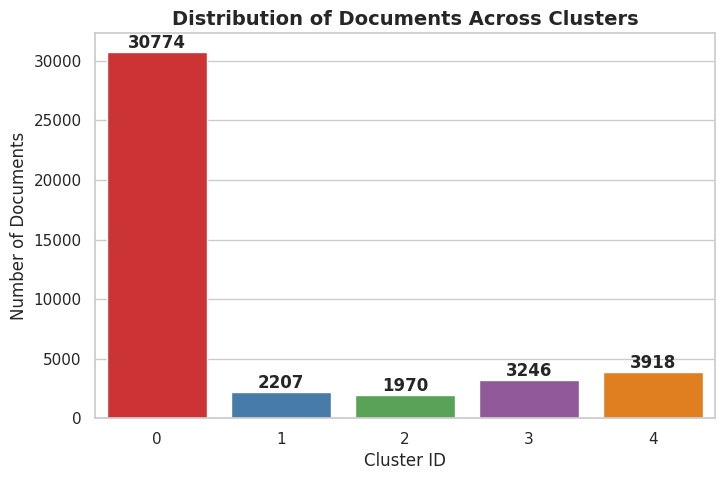

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np

# Set the visual style for professional-looking reports
sns.set_theme(style="whitegrid")

# ==========================================
# VISUALIZATION 2: Cluster Distribution Bar Chart
# ==========================================
plt.figure(figsize=(8, 5))
cluster_counts = df['cluster'].value_counts().sort_index()

# Create a bar chart showing how many articles are in each cluster
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='Set1')

plt.title('Distribution of Documents Across Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Number of Documents', fontsize=12)

# Add the exact count numbers on top of each bar
for i, count in enumerate(cluster_counts.values):
    plt.text(i, count + 2, str(count), ha='center', va='bottom', fontweight='bold')

# Save the bar chart as a PNG file for your report
plt.savefig('cluster_distribution.png', dpi=300, bbox_inches='tight')
print("Saved bar chart as 'cluster_distribution.png'")
plt.show()